In [33]:
%load_ext autoreload
%autoreload 2
import numpy as np
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import global_land_mask as globe
from scipy.stats import (
    binned_statistic_2d
)
from src.samples import (
    load_gpm_dyamond_features
)
from src.plotting import (
    discrete_cmap, 
    source_line_params
)
from src.saving import (
    save_figure
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
feature_stats_dict_0p05 = load_gpm_dyamond_features()

# Make maps of PF and ExPF locations

In [60]:
def _compute_pdf_map(df, dx, lat_lims=(-22, 22), lon_lims=(-180, 180)):

    lat_bins = np.arange(lat_lims[0], lat_lims[1] + dx, dx)
    lon_bins = np.arange(lon_lims[0], lon_lims[1] + dx, dx)

    lat = df['centroid_lat'].to_numpy()
    lon = df['centroid_lon'].to_numpy()
    lon = ((lon + 180) % 360) - 180

    counts = binned_statistic_2d(
        x=lon,
        y=lat,
        values=None,
        statistic='count',
        bins=[lon_bins, lat_bins],
    ).statistic

    # binned_statistic_2d returns [x_bin, y_bin]
    # pcolormesh wants [y, x]
    data = counts.T

    # points outside lat_lims/lon_lims are dropped before this sum,
    # so the percentages add to 100 over the domain that gets plotted
    data = 100 * data / np.nansum(data)

    return data, lon_bins, lat_bins

def _plot_pdf_map(data, lon_bins, lat_bins, ax=None, norm=None, cmap=None,
                  coastline_color=None, diff=False, cbar=False, extend=None,
                  cbar_kwargs=None, left_labels=True, right_labels=True,
                  bottom_labels=True):

    if norm is None:
        norm = colors.Normalize(vmin=-0.1, vmax=0.1) if diff else colors.Normalize(vmin=0.0, vmax=0.25)
    if cmap is None:
        cmap = plt.cm.RdBu_r if diff else plt.cm.magma
    if coastline_color is None:
        coastline_color = 'black' if diff else 'white'
    if extend is None:
        extend = 'both' if diff else 'max'

    if ax is None:
        fig, ax = plt.subplots(
            figsize=(6, 3),
            subplot_kw={"projection": ccrs.PlateCarree(central_longitude=0)},
        )
    else:
        fig = ax.get_figure()

    ax.set_aspect('auto')

    im = ax.pcolormesh(
        lon_bins,
        lat_bins,
        data,
        cmap=cmap,
        norm=norm,
        transform=ccrs.PlateCarree(),
        shading="auto",
    )

    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        xlocs=[-160, -90, 0, 90, 160],
        ylocs=np.arange(-60, 60, 15),
        linewidth=1,
        linestyle="dotted",
        color="darkgrey",
        alpha=1,
    )
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.left_labels = left_labels
    gl.right_labels = right_labels
    gl.bottom_labels = bottom_labels
    gl.top_labels = False

    ax.coastlines(color=coastline_color, linewidth=0.75)

    EPS = 1e-6
    ax.set_extent([lon_bins[0] + EPS, lon_bins[-1] - EPS, lat_bins[0], lat_bins[-1]],
                  crs=ccrs.PlateCarree())

    # Colorbar on its own (horizontal) figure.
    if cbar:
        cbar_kwargs = {} if cbar_kwargs is None else dict(cbar_kwargs)
        cbar_kwargs.pop("orientation", None)  # always horizontal

        cbar_fig, cbar_ax = plt.subplots(figsize=(4, 0.4))
        cbar_fig.colorbar(
            plt.cm.ScalarMappable(norm=norm, cmap=cmap),
            cax=cbar_ax,
            orientation="horizontal",
            extend=extend,
            **cbar_kwargs,
        )
        cbar_fig.subplots_adjust(left=0.05, right=0.95, bottom=0.5, top=0.9)
    else:
        cbar_fig = None

    return fig, ax, im, cbar_fig

## All Features

Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/pf_pdf_GPM.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/pf_pdf_cbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/pf_pdf_GEOS.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/pf_pdf_gSAM.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/pf_pdf_ICON.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/pf_pdf_SCREAM.pdf as PDF ...


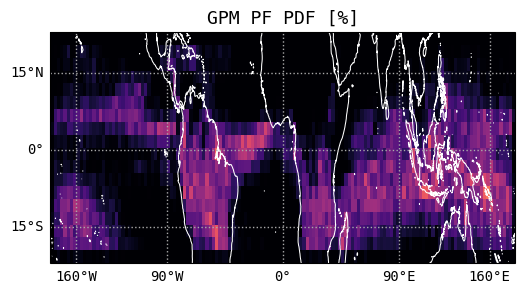

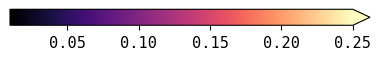

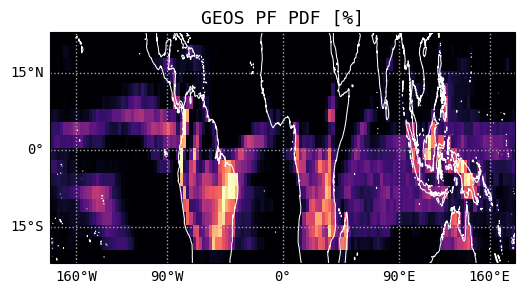

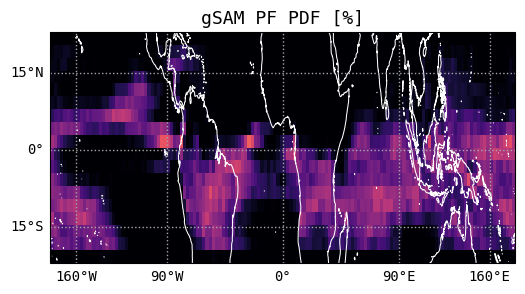

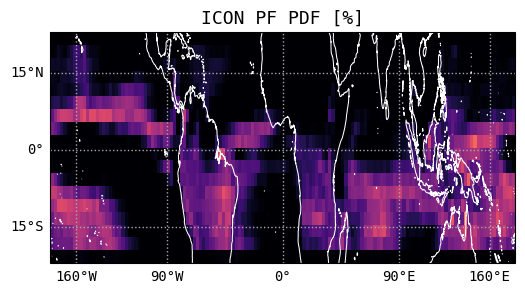

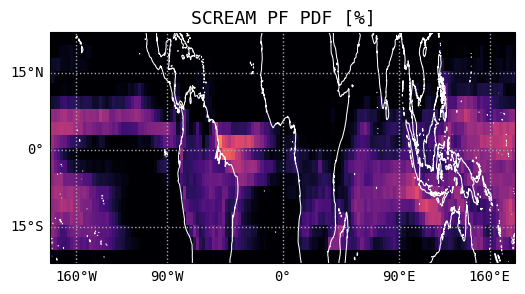

In [61]:
dx = 2.5

_, lon_bins, lat_bins = _compute_pdf_map(feature_stats_dict_0p05['GPM'], dx=dx)

norm_obs = colors.Normalize(vmin=0.01, vmax=0.25)

for i, (source, df) in enumerate(feature_stats_dict_0p05.items()):
    data, _, _ = _compute_pdf_map(df, dx=dx)

    want_cbar = (i == 0)

    fig, ax, im, cbar_fig = _plot_pdf_map(
        data, lon_bins, lat_bins,
        norm=norm_obs, diff=False, cbar=want_cbar, right_labels=False,
    )
    ax.set_title(f'{source} PF PDF [%]')
    save_figure(fig, f'pf_pdf_{source}.pdf')

    if cbar_fig is not None:
        save_figure(cbar_fig, 'pf_pdf_cbar.pdf')

## Extremes

Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/expf_pdf_GPM.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/expf_pdf_cbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/expf_pdf_GEOS.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/expf_pdf_gSAM.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/expf_pdf_ICON.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/expf_pdf_SCREAM.pdf as PDF ...


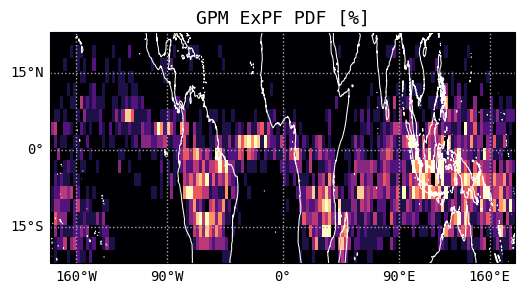

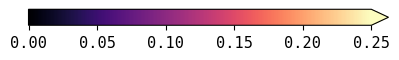

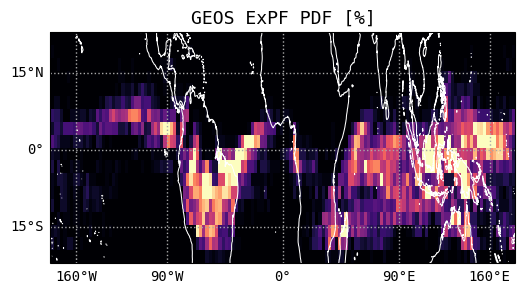

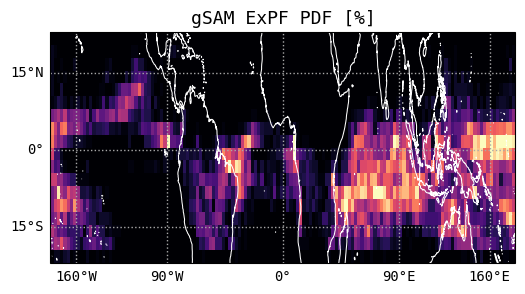

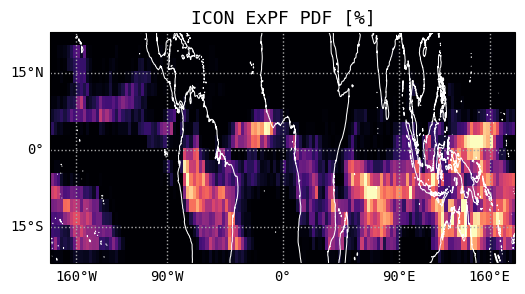

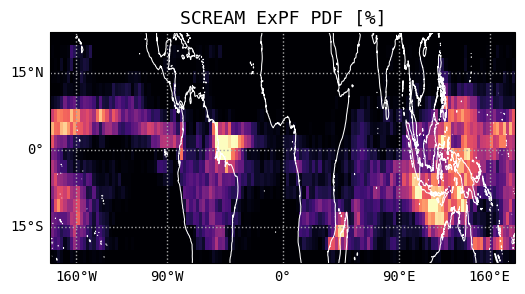

In [37]:

dx = 2.5

_, lon_bins, lat_bins = _compute_pdf_map(feature_stats_dict_0p05['GPM'], dx=dx)
norm_obs = colors.Normalize(vmin=0.0, vmax=0.25)

for i, (source, df) in enumerate(feature_stats_dict_0p05.items()):

        thresh = df['max_precip_mm_hr'].quantile(0.95)
        df = df.filter(
        pl.col("max_precip_mm_hr")>= thresh     
        )

        data, _, _ = _compute_pdf_map(df, dx=dx)

        want_cbar = (i == 0)

        fig, ax, im, cbar_fig = _plot_pdf_map(
        data, lon_bins, lat_bins,
        norm=norm_obs, diff=False, cbar=want_cbar, right_labels=False,
        )
        ax.set_title(f'{source} ExPF PDF [%]')
        save_figure(fig, f'expf_pdf_{source}.pdf')

        if cbar_fig is not None:
                save_figure(cbar_fig, 'expf_pdf_cbar.pdf')

# Land-Ocean Contrast

In [38]:
WEIGHT_COL = "total_precip_mm_hr_km2"   # set to None to skip the second column
EXTREME_Q = 0.95

LAT_MIN, LAT_MAX = -22.0, 22.0    # same domain as the maps

# --- cosine-weighted land/ocean area fractions of the domain ---
_lat = np.arange(LAT_MIN + 0.125, LAT_MAX, 0.25)
_lon = np.arange(-179.875, 180, 0.25)
_LON, _LAT = np.meshgrid(_lon, _lat)
_w = np.cos(np.deg2rad(_LAT))
f_land = float((_w * globe.is_land(_LAT, _LON)).sum() / _w.sum())
f_ocean = 1.0 - f_land
print(f"Domain {LAT_MIN:.1f} to {LAT_MAX:.1f} deg: land {f_land:.1%}, ocean {f_ocean:.1%}\n")

# --- per-source land/ocean contrast ---
sources = []
occ_all, occ_ext = [], []
pcp_all, pcp_ext = [], []

for source, df in feature_stats_dict_0p05.items():

    thresh = df["max_precip_mm_hr"].quantile(EXTREME_Q)
    df_ext = df.filter(pl.col("max_precip_mm_hr") >= thresh)

    for df_sub, out_occ, out_pcp in ((df, occ_all, pcp_all),
                                     (df_ext, occ_ext, pcp_ext)):

        lat = df_sub["centroid_lat"].to_numpy()
        lon = (df_sub["centroid_lon"].to_numpy() + 180.0) % 360.0 - 180.0
        on_land = globe.is_land(lat, lon)

        # occurrence: every feature counts once
        wt = np.ones(len(on_land))
        out_occ.append(np.log2((wt[on_land].sum() / f_land) /
                               (wt[~on_land].sum() / f_ocean)))

        # weighted: sum the column instead
        if WEIGHT_COL is not None:
            wt = df_sub[WEIGHT_COL].to_numpy()
            out_pcp.append(np.log2((wt[on_land].sum() / f_land) /
                                   (wt[~on_land].sum() / f_ocean)))

    sources.append(source)
    print(f"{source:>7}: occ all {occ_all[-1]:+.2f}  ext {occ_ext[-1]:+.2f}"
          f"   (n={df.height:,} / {df_ext.height:,}, thresh={thresh:.1f} mm/hr)")

occ_all, occ_ext = np.array(occ_all), np.array(occ_ext)
pcp_all, pcp_ext = np.array(pcp_all), np.array(pcp_ext)

Domain -22.0 to 22.0 deg: land 24.2%, ocean 75.8%

    GPM: occ all +0.37  ext +0.86   (n=62,059 / 3,104, thresh=84.1 mm/hr)
   GEOS: occ all +1.44  ext +0.87   (n=321,979 / 16,100, thresh=88.2 mm/hr)
   gSAM: occ all +0.07  ext -0.89   (n=309,108 / 15,456, thresh=69.3 mm/hr)
   ICON: occ all +0.11  ext +0.15   (n=628,422 / 31,422, thresh=125.9 mm/hr)
 SCREAM: occ all -0.50  ext -0.31   (n=636,968 / 31,849, thresh=76.3 mm/hr)


Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/landocean_GPM.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/landocean_GEOS.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/landocean_gSAM.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/landocean_ICON.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/landocean_SCREAM.pdf as PDF ...


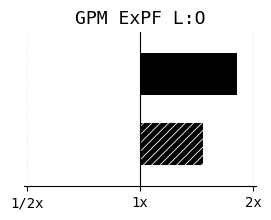

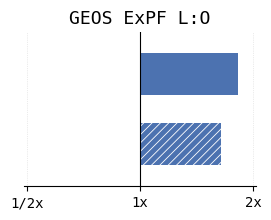

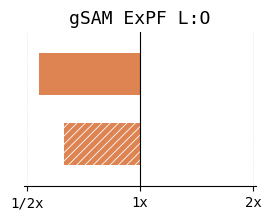

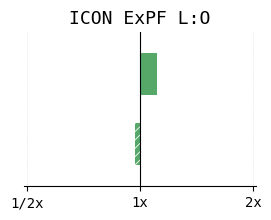

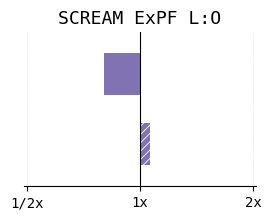

In [53]:
def _plot_land_ocean_bar(c_occ, c_pcp, color, xlim, figsize=(3, 2),
                         xlabels=True, fontsize=10):
    """Two-bar strip for a single source: occurrence and total precip."""

    fig, ax = plt.subplots(figsize=figsize)

    plt.rcParams['hatch.linewidth'] = 0.6

    ax.barh(0, c_occ, 0.6, color=color, zorder=2)
    ax.barh(1, c_pcp, 0.6, color=color, hatch="////",
            edgecolor="white", linewidth=0, zorder=2)

    ax.axvline(0, color="k", lw=0.8, zorder=3)
    for xv in (-1, 1):
        ax.axvline(xv, color="0.85", lw=0.5, ls=":", zorder=0)

    ax.set_ylim(1.6, -0.6)
    ax.set_xlim(*xlim)

    if xlabels:
        ax.set_xticks([-1, 0, 1], ["1/2x", "1x", "2x"], fontsize=fontsize)
    else:
        ax.set_xticks([-1, 0, 1], [])

    ax.set_yticks([])
    ax.tick_params(axis="y", length=0)
    ax.spines[["top", "right", "left"]].set_visible(False)

    return fig, ax


# extremes only, so the shared range comes from the two ExPF arrays
m = 1.15 * np.abs(np.concatenate([occ_ext, pcp_ext])).max()

for k, source in enumerate(sources):
    fig, ax = _plot_land_ocean_bar(
        occ_ext[k], pcp_ext[k],
        color=source_line_params(source)["color"],
        xlim=(-m, m), xlabels=True,
    )
    ax.set_title(f'{source} ExPF L:O')
    save_figure(fig, f'landocean_{source}.pdf')

Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/landocean_legend.pdf as PDF ...


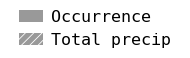

In [56]:
plt.rcParams['hatch.linewidth'] = 0.6

fig, ax = plt.subplots(figsize=(2.2, 0.4))
ax.axis('off')

handles = [plt.Rectangle((0, 0), 1, 1, facecolor="0.6"),
           plt.Rectangle((0, 0), 1, 1, facecolor="0.6", hatch="////",
                         edgecolor="white", linewidth=0)]

ax.legend(handles, ["Occurrence", "Total precip"],
          loc='center', ncol=1, fontsize=12, frameon=False,
          handlelength=1.4, handletextpad=0.5, columnspacing=1.2,
          borderpad=0)

save_figure(fig, 'landocean_legend.pdf')

Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/landocean_legend.pdf as PDF ...


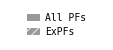

In [42]:
plt.rcParams['hatch.linewidth'] = 0.6

fig, ax = plt.subplots(figsize=(1.2, 0.4))
ax.axis('off')

handles = [plt.Rectangle((0, 0), 1, 1, facecolor="0.6"),
           plt.Rectangle((0, 0), 1, 1, facecolor="0.6", hatch="////",
                         edgecolor="white", linewidth=0)]

ax.legend(handles, ["All PFs", "ExPFs"],
          loc='center', fontsize=7, frameon=False,
          handlelength=1.4, handletextpad=0.5, labelspacing=0.4,
          borderpad=0)

save_figure(fig, 'landocean_legend.pdf')

Domain -20.0 to 20.0 deg: land 23.7%, ocean 76.3%

    GPM: all +0.40   extreme +0.90   (n=62,059 / 3,104, thresh=84.1 mm/hr)
 ARPEGE: all +0.11   extreme -0.18   (n=393,895 / 19,696, thresh=51.9 mm/hr)
   GEOS: all +1.47   extreme +0.91   (n=321,979 / 16,100, thresh=88.2 mm/hr)
  GRIST: all -0.46   extreme -0.60   (n=462,377 / 23,120, thresh=59.5 mm/hr)
   gSAM: all +0.11   extreme -0.86   (n=309,108 / 15,456, thresh=69.3 mm/hr)
   ICON: all +0.14   extreme +0.19   (n=628,422 / 31,422, thresh=125.9 mm/hr)
   MPAS: all +0.44   extreme -0.84   (n=217,015 / 10,852, thresh=73.3 mm/hr)
 SCREAM: all -0.46   extreme -0.28   (n=636,968 / 31,849, thresh=76.3 mm/hr)
 SHiELD: all +0.34   extreme +0.45   (n=233,398 / 11,671, thresh=59.6 mm/hr)
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/LandOcean_PF_ExPF_Occurrence.pdf as PDF ...


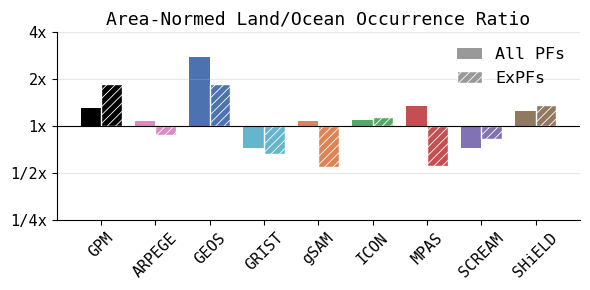

In [49]:
# ============================================================
# THE QUANTITY BEING COMPARED OVER LAND VS OCEAN
# Set to None to count features (occurrence frequency).
# Set to a column name to sum that column instead
# (e.g. "precip_volume_m3", "total_precip_mm_hr", "area_km2").
WEIGHT_COL = None
# ============================================================

EXTREME_Q = 0.95

# --- cosine-weighted land/ocean area fractions of the domain ---
lat_min = min(df["centroid_lat"].min() for df in feature_stats_dict_0p05.values())
lat_max = max(df["centroid_lat"].max() for df in feature_stats_dict_0p05.values())

_lat = np.arange(lat_min + 0.125, lat_max, 0.25)
_lon = np.arange(-179.875, 180, 0.25)
_LON, _LAT = np.meshgrid(_lon, _lat)
_w = np.cos(np.deg2rad(_LAT))
f_land = float((_w * globe.is_land(_LAT, _LON)).sum() / _w.sum())
f_ocean = 1.0 - f_land
print(f"Domain {lat_min:.1f} to {lat_max:.1f} deg: land {f_land:.1%}, ocean {f_ocean:.1%}\n")

# --- per-source land/ocean contrast ---
sources, contrast_all, contrast_ext = [], [], []

for source, df in feature_stats_dict_0p05.items():
    thresh = df["max_precip_mm_hr"].quantile(EXTREME_Q)
    df_ext = df.filter(pl.col("max_precip_mm_hr") >= thresh)

    for df_sub, out in ((df, contrast_all), (df_ext, contrast_ext)):
        lat = df_sub["centroid_lat"].to_numpy()
        lon = (df_sub["centroid_lon"].to_numpy() + 180.0) % 360.0 - 180.0
        on_land = globe.is_land(lat, lon)

        # weight per feature: 1 for occurrence, or the column value
        wt = np.ones(len(on_land)) if WEIGHT_COL is None else df_sub[WEIGHT_COL].to_numpy()

        land_total = wt[on_land].sum()
        ocean_total = wt[~on_land].sum()
        out.append(np.log2((land_total / f_land) / (ocean_total / f_ocean)))

    sources.append(source)
    print(f"{source:>7}: all {contrast_all[-1]:+.2f}   extreme {contrast_ext[-1]:+.2f}"
          f"   (n={df.height:,} / {df_ext.height:,}, thresh={thresh:.1f} mm/hr)")

# --- grouped bar chart ---
colors = [source_line_params(s)['color'] for s in sources]
x = np.arange(len(sources))
w = 0.38

plt.rcParams['hatch.linewidth'] = 0.6  # thinner white stripes

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(x - w/2, contrast_all, w, color=colors)
ax.bar(x + w/2, contrast_ext, w, color=colors, hatch="////", edgecolor="white")

ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x, sources, rotation=45)
ax.set_yticks([-2, -1, 0, 1, 2], ["1/4x", "1/2x", "1x", "2x", "4x"])
ax.set_title(f"Area-Normed Land/Ocean Occurrence Ratio")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)

# legend for the fill pattern only, since color now encodes source
handles = [plt.Rectangle((0, 0), 1, 1, facecolor="0.6"),
           plt.Rectangle((0, 0), 1, 1, facecolor="0.6", hatch="////", edgecolor="white")]
ax.legend(handles, ["All PFs", f"ExPFs"], frameon=False)

fig.tight_layout()
save_figure(fig, 'LandOcean_PF_ExPF_Occurrence.pdf')

Domain -20.0 to 20.0 deg: land 23.7%, ocean 76.3%

    GPM: all +0.53   extreme +0.59   (n=62,059 / 3,104, thresh=84.1 mm/hr)
 ARPEGE: all +0.20   extreme -0.04   (n=393,895 / 19,696, thresh=51.9 mm/hr)
   GEOS: all +1.31   extreme +0.75   (n=321,979 / 16,100, thresh=88.2 mm/hr)
  GRIST: all -0.19   extreme -0.16   (n=462,377 / 23,120, thresh=59.5 mm/hr)
   gSAM: all -0.09   extreme -0.64   (n=309,108 / 15,456, thresh=69.3 mm/hr)
   ICON: all +0.18   extreme -0.01   (n=628,422 / 31,422, thresh=125.9 mm/hr)
   MPAS: all -0.20   extreme -0.90   (n=217,015 / 10,852, thresh=73.3 mm/hr)
 SCREAM: all -0.08   extreme +0.12   (n=636,968 / 31,849, thresh=76.3 mm/hr)
 SHiELD: all +0.29   extreme +0.35   (n=233,398 / 11,671, thresh=59.6 mm/hr)
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/LandOcean_PF_ExPF_TotalPrecip.pdf as PDF ...


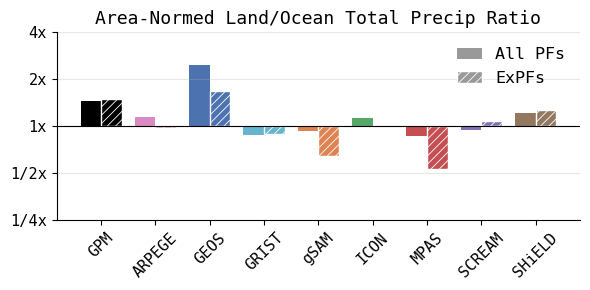

In [50]:
# ============================================================
# THE QUANTITY BEING COMPARED OVER LAND VS OCEAN
# Set to None to count features (occurrence frequency).
# Set to a column name to sum that column instead
# (e.g. "precip_volume_m3", "total_precip_mm_hr", "area_km2").
WEIGHT_COL = "total_precip_mm_hr_km2"
# ============================================================

EXTREME_Q = 0.95

# --- cosine-weighted land/ocean area fractions of the domain ---
lat_min = min(df["centroid_lat"].min() for df in feature_stats_dict_0p05.values())
lat_max = max(df["centroid_lat"].max() for df in feature_stats_dict_0p05.values())

_lat = np.arange(lat_min + 0.125, lat_max, 0.25)
_lon = np.arange(-179.875, 180, 0.25)
_LON, _LAT = np.meshgrid(_lon, _lat)
_w = np.cos(np.deg2rad(_LAT))
f_land = float((_w * globe.is_land(_LAT, _LON)).sum() / _w.sum())
f_ocean = 1.0 - f_land
print(f"Domain {lat_min:.1f} to {lat_max:.1f} deg: land {f_land:.1%}, ocean {f_ocean:.1%}\n")

# --- per-source land/ocean contrast ---
sources, contrast_all, contrast_ext = [], [], []

for source, df in feature_stats_dict_0p05.items():
    thresh = df["max_precip_mm_hr"].quantile(EXTREME_Q)
    df_ext = df.filter(pl.col("max_precip_mm_hr") >= thresh)

    for df_sub, out in ((df, contrast_all), (df_ext, contrast_ext)):
        lat = df_sub["centroid_lat"].to_numpy()
        lon = (df_sub["centroid_lon"].to_numpy() + 180.0) % 360.0 - 180.0
        on_land = globe.is_land(lat, lon)

        # weight per feature: 1 for occurrence, or the column value
        wt = np.ones(len(on_land)) if WEIGHT_COL is None else df_sub[WEIGHT_COL].to_numpy()

        land_total = wt[on_land].sum()
        ocean_total = wt[~on_land].sum()
        out.append(np.log2((land_total / f_land) / (ocean_total / f_ocean)))

    sources.append(source)
    print(f"{source:>7}: all {contrast_all[-1]:+.2f}   extreme {contrast_ext[-1]:+.2f}"
          f"   (n={df.height:,} / {df_ext.height:,}, thresh={thresh:.1f} mm/hr)")

# --- grouped bar chart ---
colors = [source_line_params(s)['color'] for s in sources]
x = np.arange(len(sources))
w = 0.38

plt.rcParams['hatch.linewidth'] = 0.6  # thinner white stripes

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(x - w/2, contrast_all, w, color=colors)
ax.bar(x + w/2, contrast_ext, w, color=colors, hatch="////", edgecolor="white")

ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x, sources, rotation=45)
ax.set_yticks([-2, -1, 0, 1, 2], ["1/4x", "1/2x", "1x", "2x", "4x"])
ax.set_title(f"Area-Normed Land/Ocean Total Precip Ratio")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)

# legend for the fill pattern only, since color now encodes source
handles = [plt.Rectangle((0, 0), 1, 1, facecolor="0.6"),
           plt.Rectangle((0, 0), 1, 1, facecolor="0.6", hatch="////", edgecolor="white")]
ax.legend(handles, ["All PFs", f"ExPFs"], frameon=False)

fig.tight_layout()
save_figure(fig, 'LandOcean_PF_ExPF_TotalPrecip.pdf')

# Sensitivity Sweeps

## Maps and Edge Frac Max

Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/sensitivity/MapPFs_GPM_EdgeFracMax0.0.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/sensitivity/MapPFs_EdgeFracMax0.0_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/sensitivity/MapPFs_GEOS_EdgeFracMax0.0.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/sensitivity/MapPFs_EdgeFracMax0.0_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/sensitivity/MapPFs_SCREAM_EdgeFracMax0.0.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/sensitivity/MapPFs_EdgeFracMax0.0_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/sensitivity/MapPFs_SHiELD_EdgeFracMax0.0.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/sensiti

/var/folders/1t/6drgwyc17q12xmq4h7m454vw0000gn/T/ipykernel_24101/3955006119.py:41: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(


Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/sensitivity/MapPFs_EdgeFracMax0.05_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/sensitivity/MapPFs_MPAS_EdgeFracMax0.05.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/sensitivity/MapPFs_EdgeFracMax0.05_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/sensitivity/MapPFs_gSAM_EdgeFracMax0.05.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/sensitivity/MapPFs_EdgeFracMax0.05_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/sensitivity/MapPFs_ICON_EdgeFracMax0.05.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/sensitivity/MapPFs_EdgeFracMax0.05_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures

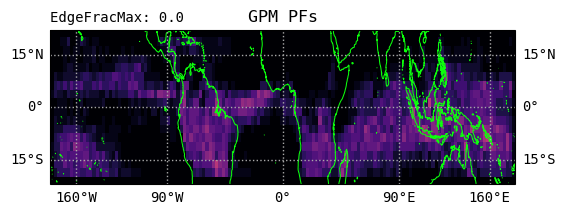

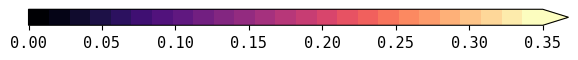

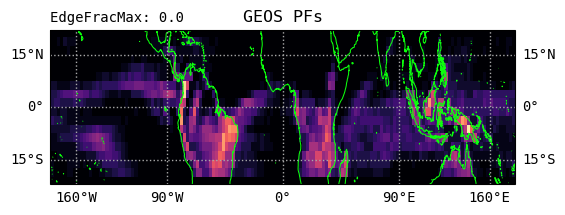

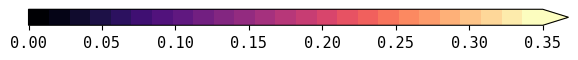

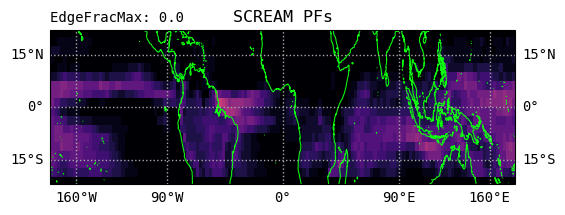

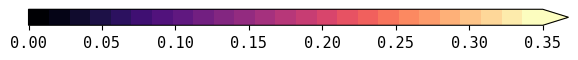

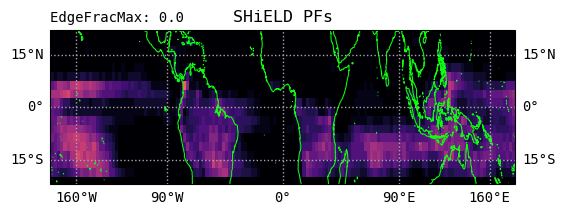

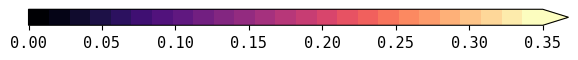

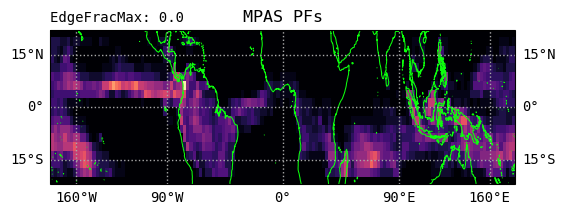

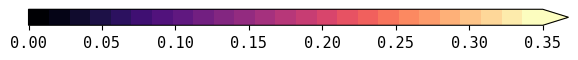

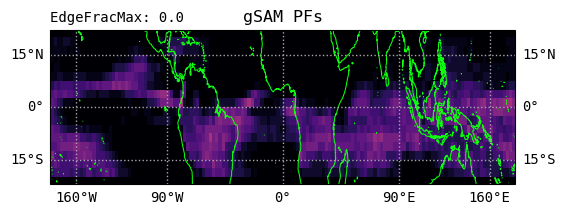

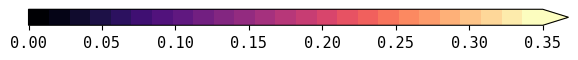

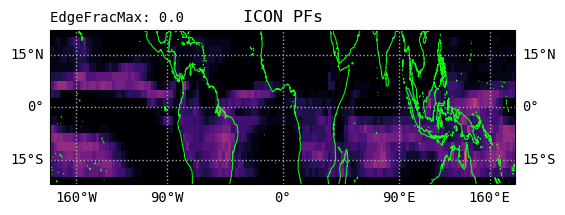

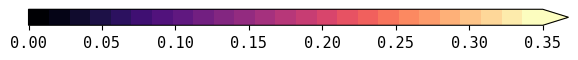

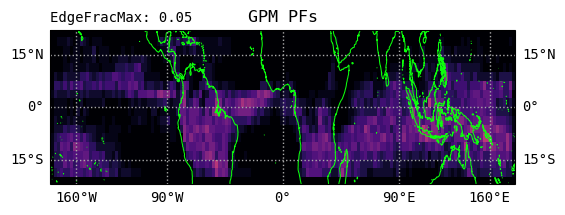

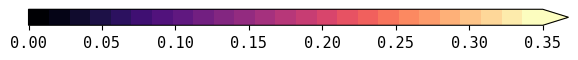

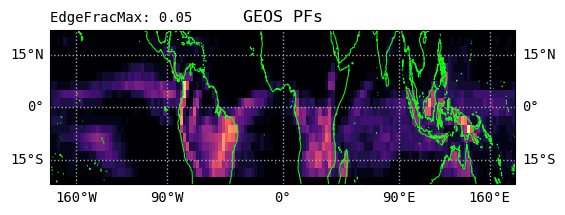

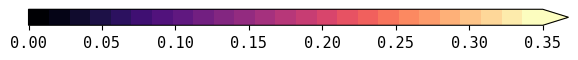

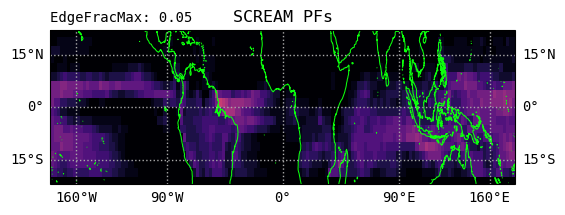

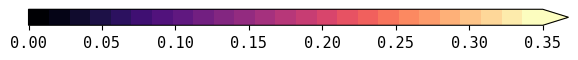

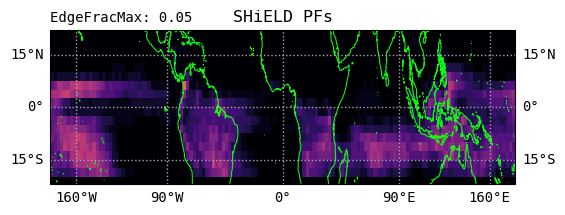

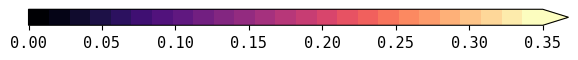

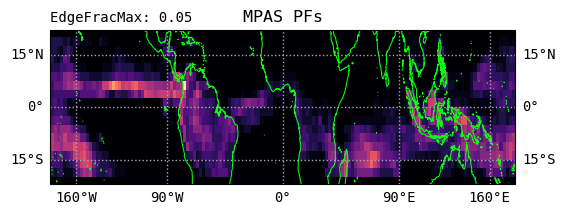

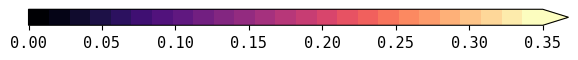

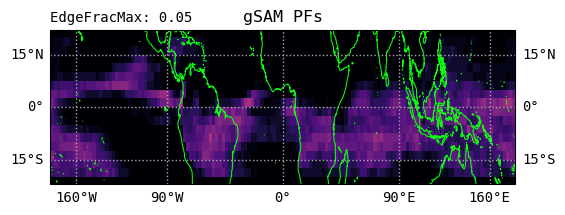

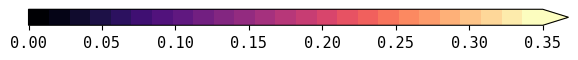

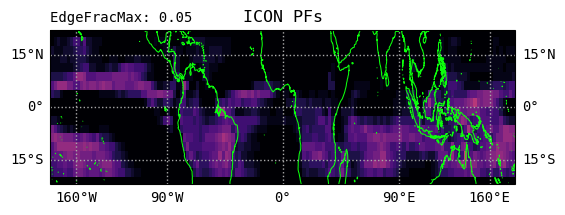

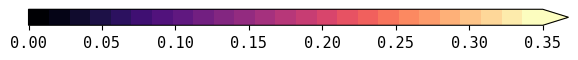

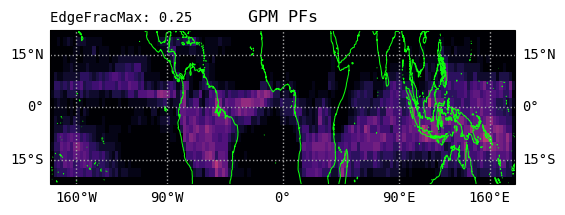

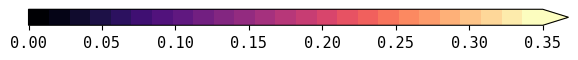

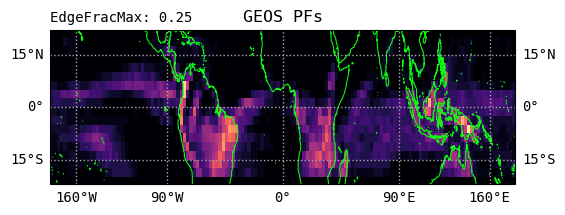

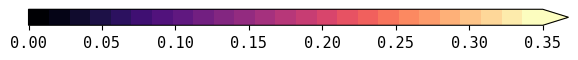

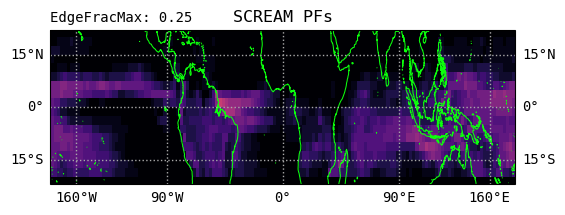

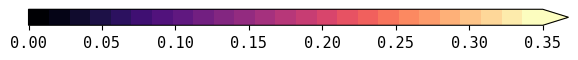

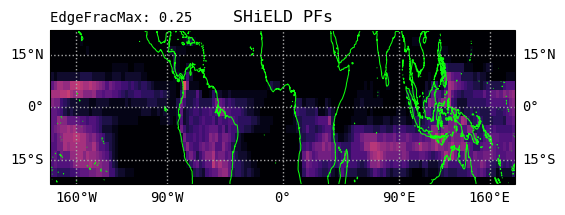

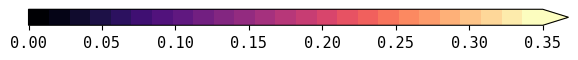

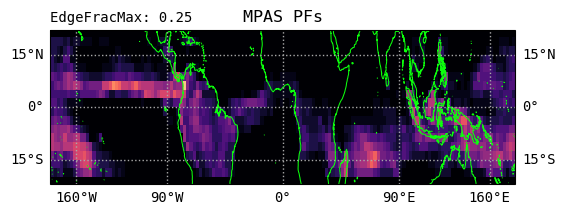

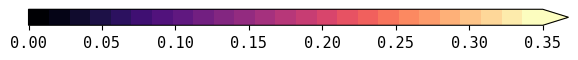

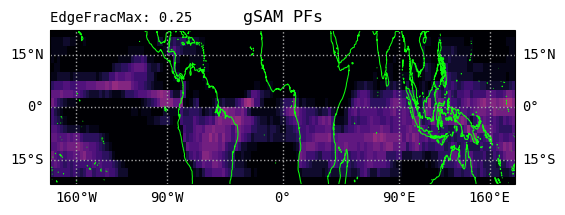

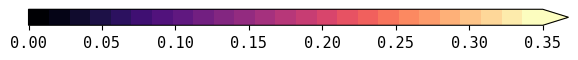

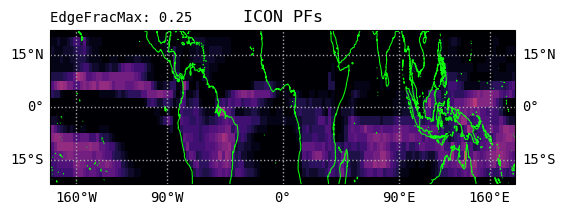

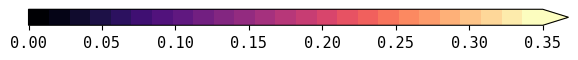

In [5]:
_RES = "0p05"
_ACCUM = "15min"
edge_frac_max_list = [0.0, 0.05, 0.25]

for _EDGE_FRAC_MAX in edge_frac_max_list:
    # Load features (IMERG is native 0.1 deg, so it takes no res argument)
    _MAX_PR_MIN = 10.0
    feature_stats_dict = {
        'GPM': load_gpm_feature_stats(threshold=1.0, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        # 'IMERG': load_imerg_feature_stats(threshold=1, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        'GEOS': load_dyamond_feature_stats('GEOS-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        'SCREAM': load_dyamond_feature_stats('SCREAM-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        'SHiELD': load_dyamond_feature_stats('SHiELD-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        'MPAS': load_dyamond_feature_stats('MPAS-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        'gSAM': load_dyamond_feature_stats('gSAM-4km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        'ICON': load_dyamond_feature_stats('ICON-SAP-5km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
    }

    for source, df in feature_stats_dict.items():
        fig, ax, cbar_fig, cbar_ax, data = _make_map(
            df,
            normalize=True,
            cmap=discrete_cmap('magma', N=25, under_color='White'),
            norm=colors.Normalize(vmin=0.0, vmax=0.35),
            coastline_color='xkcd:neon green',
            ticks=[0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35],
            return_colorbar_separate=True,
            figsize=(6,2)
        )
        ax.set_title(f'{source} PFs', fontsize=12)
        ax.set_title(f'EdgeFracMax: {_EDGE_FRAC_MAX}', loc='left', fontsize=10)
        save_figure(fig, f'sensitivity/MapExPFs_{source}_EdgeFracMax{_EDGE_FRAC_MAX}.pdf')
        save_figure(cbar_fig, f'sensitivity/MapExPFs_EdgeFracMax{_EDGE_FRAC_MAX}_colorbar.pdf')

Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapExPFs_GPM_EdgeFracMax0.0.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapExPFs_GPM_EdgeFracMax0.0_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapExPFs_GEOS_EdgeFracMax0.0.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapExPFs_GEOS_EdgeFracMax0.0_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapExPFs_SCREAM_EdgeFracMax0.0.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapExPFs_SCREAM_EdgeFracMax0.0_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapExPFs_SHiELD_EdgeFracMax0.0.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapExPFs_SHiELD_EdgeFracMax0.0_colorbar.pdf as PDF ...
Saving

/var/folders/1t/6drgwyc17q12xmq4h7m454vw0000gn/T/ipykernel_48134/3955006119.py:41: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(


Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapExPFs_SHiELD_EdgeFracMax0.05_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapExPFs_MPAS_EdgeFracMax0.05.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapExPFs_MPAS_EdgeFracMax0.05_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapExPFs_gSAM_EdgeFracMax0.05.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapExPFs_gSAM_EdgeFracMax0.05_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapExPFs_ICON_EdgeFracMax0.05.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapExPFs_ICON_EdgeFracMax0.05_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapExPFs_GPM_EdgeFracMax0.25.pdf as PDF ...
Sav

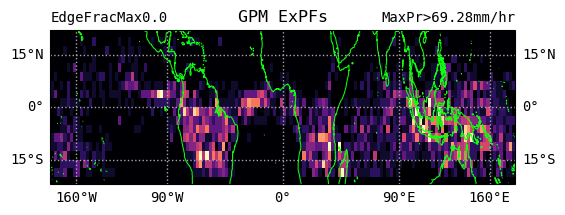

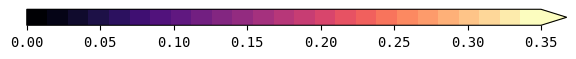

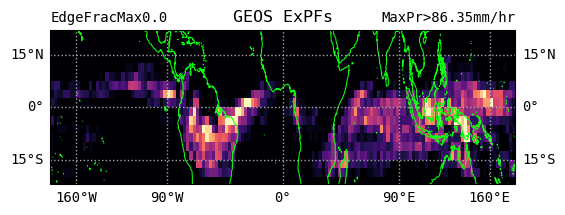

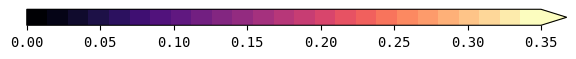

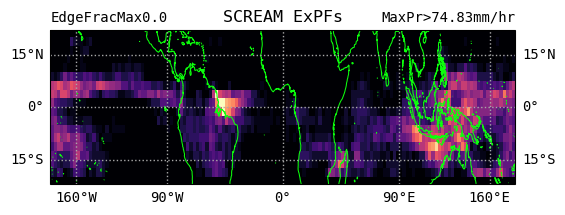

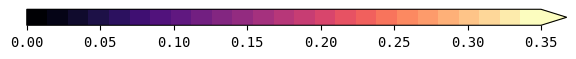

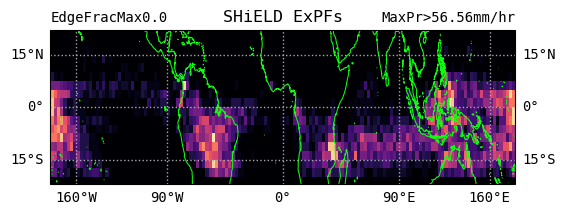

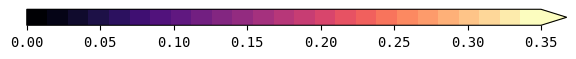

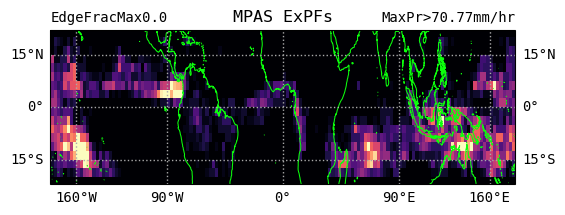

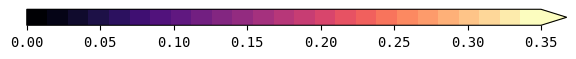

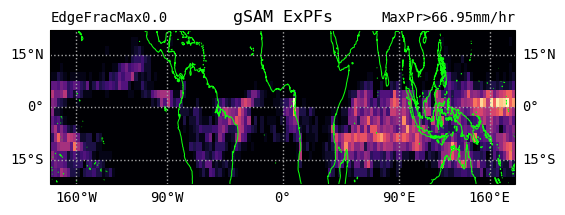

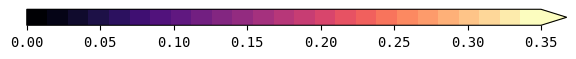

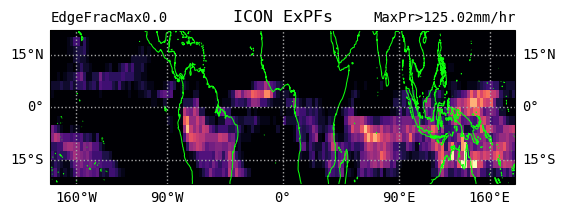

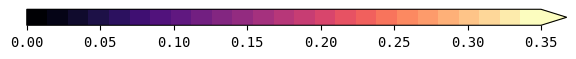

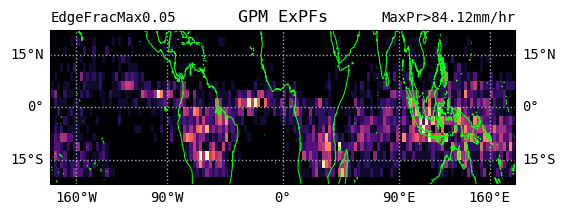

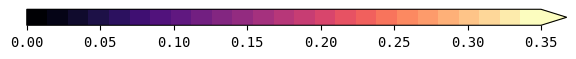

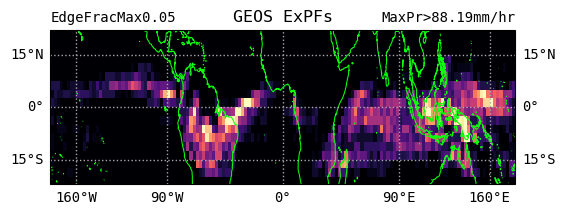

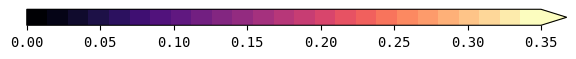

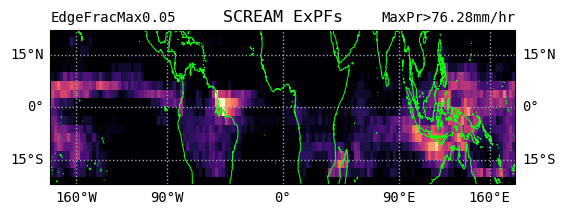

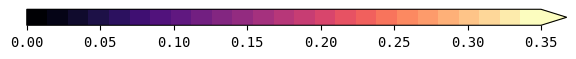

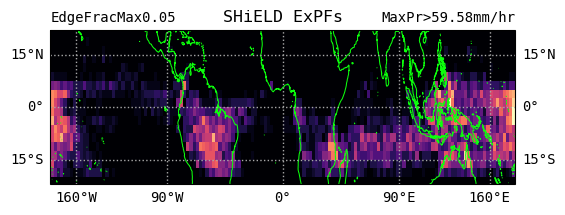

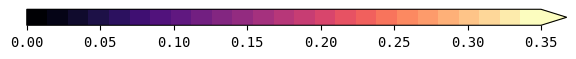

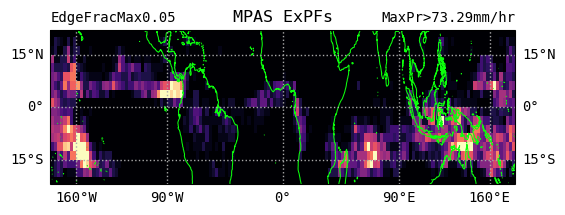

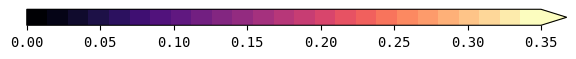

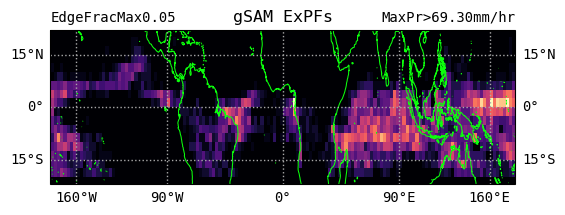

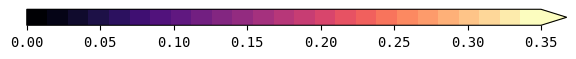

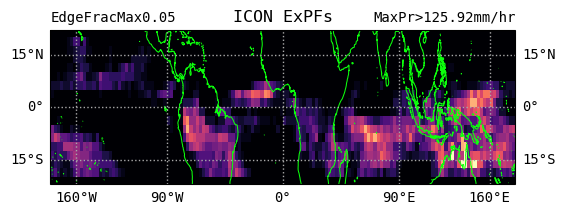

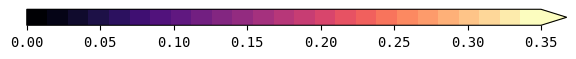

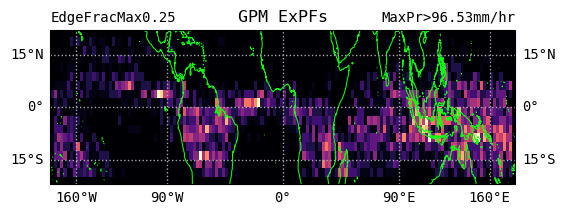

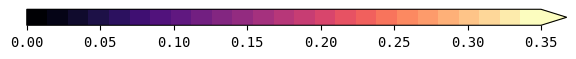

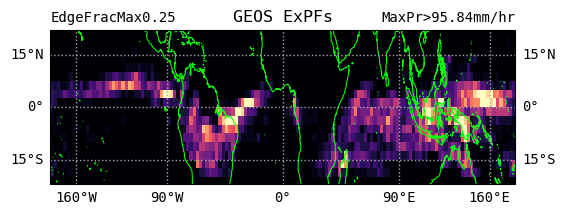

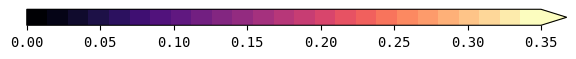

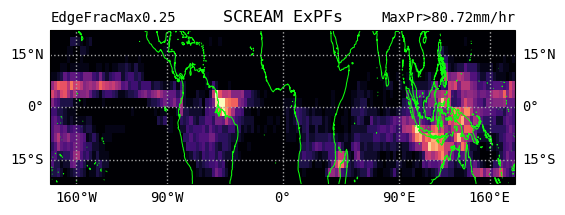

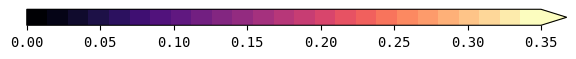

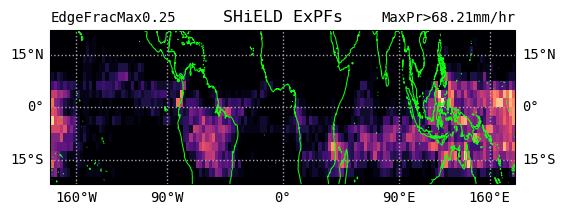

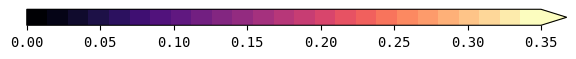

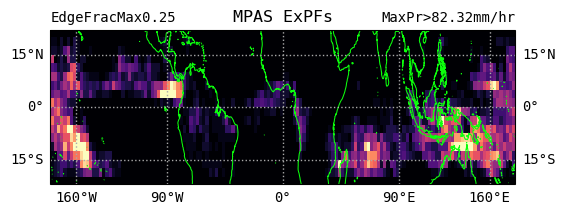

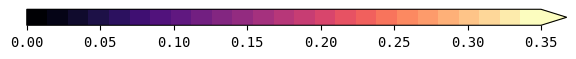

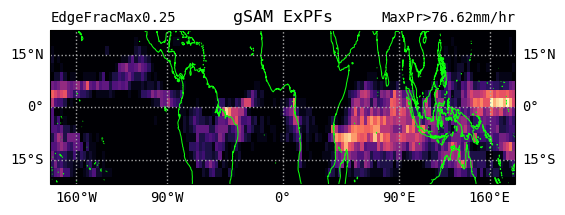

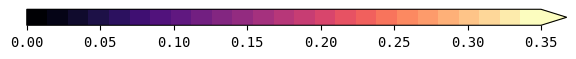

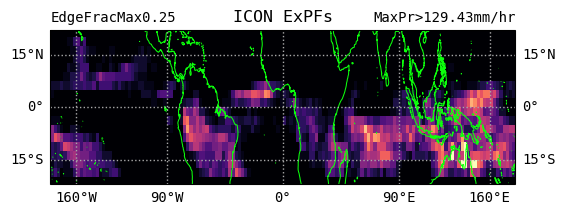

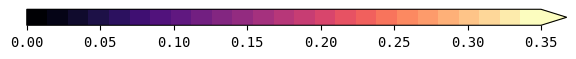

In [4]:
_RES = "0p05"
_ACCUM = "15min"
edge_frac_max_list = [0.0, 0.05, 0.25]

for _EDGE_FRAC_MAX in edge_frac_max_list:
    # Load features (IMERG is native 0.1 deg, so it takes no res argument)
    _MAX_PR_MIN = 10.0
    feature_stats_dict = {
        'GPM': load_gpm_feature_stats(threshold=1.0, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        # 'IMERG': load_imerg_feature_stats(threshold=1, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        'GEOS': load_dyamond_feature_stats('GEOS-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        'SCREAM': load_dyamond_feature_stats('SCREAM-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        'SHiELD': load_dyamond_feature_stats('SHiELD-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        'MPAS': load_dyamond_feature_stats('MPAS-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        'gSAM': load_dyamond_feature_stats('gSAM-4km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        'ICON': load_dyamond_feature_stats('ICON-SAP-5km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
    }

    for source, df in feature_stats_dict.items():
        thresh = df['max_precip_mm_hr'].quantile(0.95)
        df = df.filter(
            pl.col("max_precip_mm_hr") >= thresh
        )
        fig, ax, cbar_fig, cbar_ax, data = _make_map(
            df,
            normalize=True,
            cmap=discrete_cmap('magma', N=25, under_color='White'),
            norm=colors.Normalize(vmin=0.0, vmax=0.35),
            coastline_color='xkcd:neon green',
            ticks=[0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35],
            return_colorbar_separate=True,
            figsize=(6,2)
        )
        ax.set_title(f'{source} ExPFs', fontsize=12)
        ax.set_title(f'MaxPr>{thresh:.2f}mm/hr', loc='right', fontsize=10)
        ax.set_title(f'EdgeFracMax{_EDGE_FRAC_MAX}', loc='left', fontsize=10)
        save_figure(fig, f'MapExPFs_{source}_EdgeFracMax{_EDGE_FRAC_MAX}.pdf')
        save_figure(cbar_fig, f'MapExPFs_{source}_EdgeFracMax{_EDGE_FRAC_MAX}_colorbar.pdf')